In [48]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

current_folder = "\\".join(os.getcwd().split("\\")[:-1])

Load image and change it to process image

In [49]:
def find_matches(find_image, template_image, min_matches=10, ratio_thresh=0.7, showResult = False):
    copy_find_image = find_image.copy()
    copy_template_image = template_image.copy()

    _, thresh_copy_find_image = cv2.threshold(copy_find_image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    _, thresh_copy_template_image = cv2.threshold(template_image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    
    sift = cv2.SIFT_create()
    # detect and compute the keypoints and descriptors with SIFT
    kpFindImage, desFindImage = sift.detectAndCompute(thresh_copy_find_image, None)
    kpTemplate, desTemplate = sift.detectAndCompute(thresh_copy_template_image, None)

    # Check for insufficient keypoints
    if desFindImage is None or desTemplate is None:
        return False

    # FLANN parameters
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)  # or pass empty dictionary
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    matches = flann.knnMatch(desFindImage, desTemplate, k=2)

    # Need to draw only good matches, so create a mask
    matchesMask = [[0, 0] for i in range(len(matches))]

    # Count good matches based on ratio test
    good_matches = 0

    # ratio test as per Lowe's paper
    for i, (m, n) in enumerate(matches):
        if m.distance < ratio_thresh * n.distance:
            matchesMask[i] = [1, 0]
            good_matches += 1

    draw_params = dict(
        matchColor=(0, 255, 0),
        singlePointColor=(255, 0, 0),
        matchesMask=matchesMask,
        flags=cv2.DrawMatchesFlags_DEFAULT,
    )

    # cv2.drawMatchesKnn expects a list of lists as matches.
    imgResult = cv2.drawMatchesKnn(
        copy_find_image,
        kpFindImage,
        copy_template_image,
        kpTemplate,
        matches,
        None,
        **draw_params
    )
    isFound = good_matches >= min_matches
    if isFound or showResult:
        plt.imshow(imgResult)
        plt.show()
    return isFound

In [50]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        imgMatLike = cv2.imread(os.path.join(folder, filename), cv2.IMREAD_GRAYSCALE)
        if imgMatLike is not None:
          images.append((filename, imgMatLike))
    return images

Pre-Process Image before compare

In [51]:
def preprocess_image(image):
  # Noise reduction using Gaussian Blur
  denoised_image = cv2.GaussianBlur(image, (5, 5), 0)

  # Sharpening the image
  kernel = np.array([[0, -1, 0],
             [-1, 5,-1],
             [0, -1, 0]])
  sharpened_image = cv2.filter2D(denoised_image, -1, kernel)

  return sharpened_image

In [52]:
findImages = load_images_from_folder(os.path.join(current_folder, "images", "items"))

# Apply preprocessing to all images in findImages
preprocessed_images = [(name, preprocess_image(img)) for name, img in findImages]

Match Images

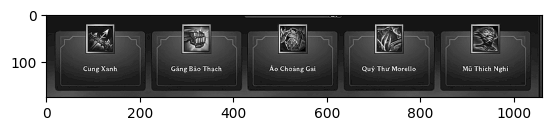

In [53]:
template = cv2.imread(os.path.join(current_folder, "images", "template", "template.png"), cv2.IMREAD_GRAYSCALE)
preprocess_template = preprocess_image(template)
plt.imshow(preprocess_template, cmap='gray')
plt.show()

for imageName, image in preprocessed_images:
    result = find_matches(image, preprocess_template)
    if result:
        print(f"Found {imageName} in template: {'Yes' if result else 'No'}")
        print("\n")